In [23]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import Kernel, RBF, WhiteKernel, Matern, ConstantKernel as C
from sklearn.gaussian_process.kernels import Hyperparameter

import jax.numpy as jnp

from jax import random
from jax.example_libraries import optimizers
from jax import jit, grad, vmap
from jax import tree_util as jtu
from jax.nn import softplus

import functools

import neural_tangents as nt
from neural_tangents import stax

import math

import torch
import torch.nn as nn
import torch.nn.functional as F
from contextlib import contextmanager


In [3]:
#Plot settings
from IPython.display import set_matplotlib_formats
set_matplotlib_formats('pdf', 'svg')
import matplotlib
import seaborn as sns

sns.set(font_scale=1.3)
sns.set_style("darkgrid", {"axes.facecolor": ".95"})

import matplotlib.pyplot as plt

def format_plot(x=None, y=None):
  # plt.grid(False)
  ax = plt.gca()
  if x is not None:
    plt.xlabel(x, fontsize=20)
  if y is not None:
    plt.ylabel(y, fontsize=20)

def finalize_plot(shape=(1, 1)):
  plt.gcf().set_size_inches(
    shape[0] * 1.5 * plt.gcf().get_size_inches()[1],
    shape[1] * 1.5 * plt.gcf().get_size_inches()[1])
  plt.tight_layout()

legend = functools.partial(plt.legend, fontsize=10)

def plot_fn(train, test, *fs):
  train_xs, train_ys = train

  plt.plot(train_xs, train_ys, 'ro', markersize=10, label='train')

  if test != None:
    test_xs, test_ys = test
    plt.plot(test_xs, test_ys, 'k--', linewidth=3, label='$f(x)$')

    for f in fs:
      plt.plot(test_xs, f(test_xs), '-', linewidth=3)

  plt.xlim([-jnp.pi, jnp.pi])
  # plt.ylim([-1.5, 1.5])

  format_plot('$x$', '$f(x)$')

/var/folders/ld/k3z4_g8n0nvdb_19cpz6t30h0000gn/T/ipykernel_3535/3367370499.py:3: DeprecationWarning: `set_matplotlib_formats` is deprecated since IPython 7.23, directly use `matplotlib_inline.backend_inline.set_matplotlib_formats()`
  set_matplotlib_formats('pdf', 'svg')


In [4]:
def loss_fn(predict_fn, ys, t, xs=None):
  mean, cov = predict_fn(t=t, get='ntk', x_test=xs, compute_cov=True)
  mean = jnp.reshape(mean, mean.shape[:1] + (-1,))
  var = jnp.diagonal(cov, axis1=1, axis2=2)
  ys = jnp.reshape(ys, (1, -1))

  mean_predictions = 0.5 * jnp.mean(ys ** 2 - 2 * mean * ys + var + mean ** 2,
                                   axis=1)

  return mean_predictions

## Create data set for all approaches

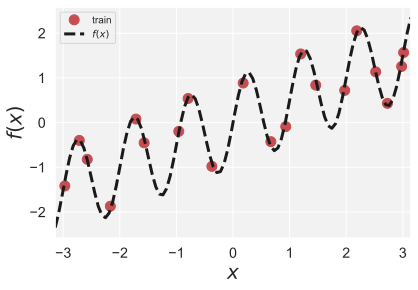

In [7]:
key = random.PRNGKey(42)

train_points = 20
test_points = 100
noise_scale = 1e-1

target_fn = lambda x: jnp.sin(2 * jnp.pi * x) +0.5*x

# Training data
key, x_key, y_key = random.split(key, 3)
train_xs = random.uniform(x_key, (train_points, 1), minval=-jnp.pi, maxval=jnp.pi)
train_ys = target_fn(train_xs)
train_ys += noise_scale * random.normal(y_key, (train_points, 1))
train = (train_xs, train_ys)

# Test data
test_xs = jnp.linspace(-jnp.pi, jnp.pi, test_points)
test_xs = jnp.reshape(test_xs, (test_points, 1))
test_ys = target_fn(test_xs)
test = (test_xs, test_ys)

plot_fn(train, test)
legend(loc='upper left')
finalize_plot((0.85, 0.6))

## NTK kernel

Implementation from cookbook

### Define Neural Network

- fully connected network using Erf non-linearities
- further information: neural_tangents_cookbook.ipynb

Fully-connected layers in `neural_tangents.stax` are created using the `Dense` layer which is defined by,
$$z^{l+1}_i = \frac{\sigma_w}{\sqrt{N_{in}}} \sum_j W_{ij} z^{l}_i + \sigma_b b_i$$
where $W_{ij}, b_i\sim\mathcal N(0,1)$ at initialization and $\sigma_w, \sigma_b$ sets the scales of the weights and biases respectively.

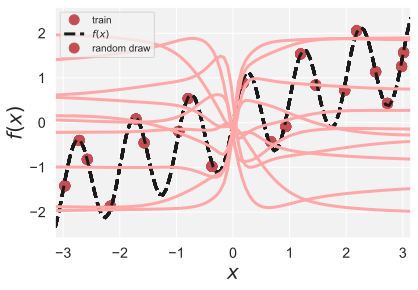

In [8]:
# init_fn, apply_fn, kernel_fn = stax.serial(
#     stax.Dense(512, W_std=1.5, b_std=0.05), stax.Erf(),
#     stax.Dense(512, W_std=1.5, b_std=0.05), stax.Erf(),
#     stax.Dense(512, W_std=1.5, b_std=0.05), stax.Erf(),
#     stax.Dense(1, W_std=1.5, b_std=0.05)
# )

# BNN Setup
init_fn, apply_fn, kernel_fn = stax.serial(
    stax.Dense(64, W_std=1.5, b_std=0.05), stax.Erf(),
    stax.Dense(64, W_std=1.5, b_std=0.05), stax.Erf(),
    stax.Dense(64, W_std=1.5, b_std=0.05), stax.Erf(),
    stax.Dense(1,  W_std=1.5, b_std=0.05)
)

apply_fn = jit(apply_fn)
kernel_fn = jit(kernel_fn, static_argnames='get')

prior_draws = []
for _ in range(10):
  key, net_key = random.split(key)
  _, params = init_fn(net_key, (-1, 1))
  prior_draws += [apply_fn(params, test_xs)]

  plot_fn(train, test)

for p in prior_draws:
  plt.plot(test_xs, p, linewidth=3, color=[1, 0.65, 0.65])

legend(['train', '$f(x)$', 'random draw'], loc='upper left')

finalize_plot((0.85, 0.6))

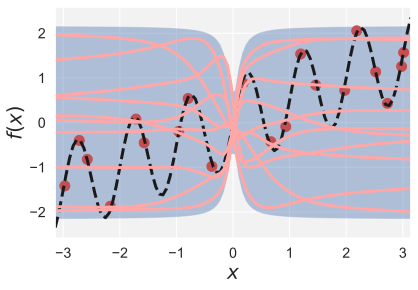

In [9]:
# look at exact prior over functions in infinite-width limit using kernel_fn
# kernel function has signature kernel = kernel_fn (x1, x2): computes kernel between two input sets
# kernel_fn can compute two different kernels: NNGP kernel and NT kernel
# NNGP: Bayesian infinite network
# NT kernel: evolution under gradient descent

kernel = kernel_fn(test_xs, test_xs, 'nngp')
std_dev = jnp.sqrt(jnp.diag(kernel))

plot_fn(train, test)

plt.fill_between(
    jnp.reshape(test_xs, (-1,)), 2 * std_dev, -2 * std_dev, alpha=0.4)

for p in prior_draws:
  plt.plot(test_xs, p, linewidth=3, color=[1, 0.65, 0.65])

finalize_plot((0.85, 0.6))

### Infinite width inference

- Use infinite-width GP to perform exact Bayesian inference using infinite width network
- use function `neural_tangents.predict.gradient_descent_mse_ensemble`
- `predict_fn = nt.predict.gradient_descent_mse_ensemble(kernel_fn, train_xs, train_ys); mean, cov = predict_fn(x_test=test_xs, get='ntk', compute_cov=True)` computes the mean and covariance of the network
- `predict_fn` has two modes: NNGP (Bayesian posterior) and NTK (distribution of networks after gradient descent)

Use this for a more linear kernel approach

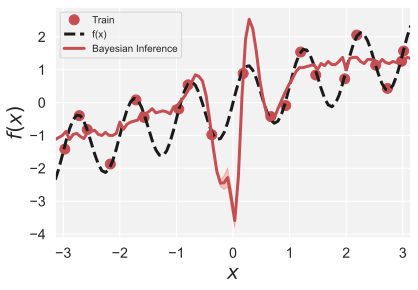

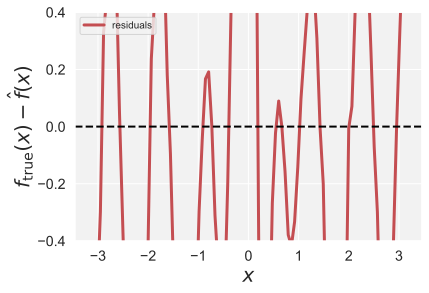

In [10]:
# start with Bayesian inference (NNGP setting)

predict_fn = nt.predict.gradient_descent_mse_ensemble(kernel_fn, train_xs,
                                                      train_ys, diag_reg=5e-6) #former 1e-4

nngp_mean, nngp_covariance = predict_fn(x_test=test_xs, get='nngp',
                                        compute_cov=True)

nngp_mean = jnp.reshape(nngp_mean, (-1,))
nngp_std = jnp.sqrt(jnp.diag(nngp_covariance))

plot_fn(train, test)

plt.plot(test_xs, nngp_mean, 'r-', linewidth=3)
plt.fill_between(
    jnp.reshape(test_xs, (-1)),
    nngp_mean - 2 * nngp_std,
    nngp_mean +  2 * nngp_std,
    color='red', alpha=0.2, label='_nolegend_')
# plt.xlim([-jnp.pi, jnp.pi])
# plt.ylim([-1.5, 1.5])
legend(['Train', 'f(x)', 'Bayesian Inference'], loc='upper left')
finalize_plot((0.85, 0.6))

residuals = np.array(test_ys).ravel() - nngp_mean.ravel()

plt.figure()
plt.plot(test_xs, residuals.reshape(-1, 1), 'r-', linewidth=3, label='residuals')
plt.axhline(0, linestyle='--', color='black', linewidth=2)
format_plot('$x$', r'$f_{\mathrm{true}}(x) - \hat{f}(x)$')
legend(loc='upper left')
finalize_plot((0.85, 0.6))
plt.ylim([-0.4, 0.4])
plt.show()

! Use this for a periodic kernel !

Introduce a periodic kernel to mimic sin behaviour since we know it's periodic

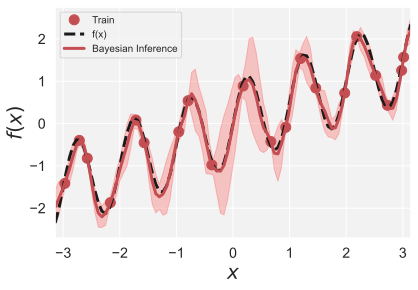

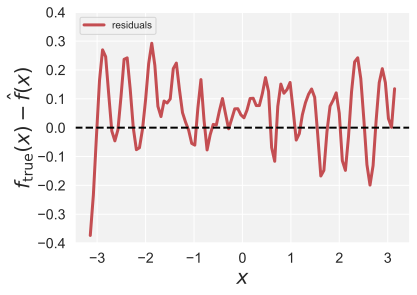

In [11]:
def periodic_kernel_fn(kernel_fn, x1, x2, get='nngp', period=1.0):
    """Apply periodic+linear feature map before calling kernel_fn."""
    def fe(x):
        if x is None:
            return None
        # x = jnp.atleast_2d(x)               
        w = (2 * jnp.pi / period) * x
        return jnp.concatenate([x, jnp.cos(w), jnp.sin(w)], axis=-1)

    return kernel_fn(fe(x1), fe(x2), get=get)


predict_fn = nt.predict.gradient_descent_mse_ensemble(
    lambda x1, x2, get: periodic_kernel_fn(kernel_fn, x1, x2, get, period=1.0),
    train_xs,
    train_ys,
    diag_reg=1e-4
)

nngp_mean, nngp_cov = predict_fn(x_test=test_xs, get='nngp', compute_cov=True)
nngp_mean = nngp_mean.reshape(-1)
nngp_std  = jnp.sqrt(jnp.diag(nngp_cov))

plot_fn(train, test)

plt.plot(test_xs, nngp_mean, 'r-', linewidth=3)
plt.fill_between(
    jnp.reshape(test_xs, (-1)),
    nngp_mean - 2 * nngp_std,
    nngp_mean +  2 * nngp_std,
    color='red', alpha=0.2, label='_nolegend_')
# plt.xlim([-jnp.pi, jnp.pi])
# plt.ylim([-1.5, 1.5])
legend(['Train', 'f(x)', 'Bayesian Inference'], loc='upper left')
finalize_plot((0.85, 0.6))

residuals = np.array(test_ys).ravel() - nngp_mean.ravel()

plt.figure()
plt.plot(test_xs, residuals.reshape(-1, 1), 'r-', linewidth=3, label='residuals')
plt.axhline(0, linestyle='--', color='black', linewidth=2)
format_plot('$x$', r'$f_{\mathrm{true}}(x) - \hat{f}(x)$')
legend(loc='upper left')
finalize_plot((0.85, 0.6))
plt.ylim([-0.4, 0.4])
plt.show()


In [25]:
# Results of NTK: gradient descent on infinite network with infinite amount of time

ntk_mean, ntk_covariance = predict_fn(x_test=test_xs, get='ntk',
                                      compute_cov=True)

ntk_mean = jnp.reshape(ntk_mean, (-1,))
ntk_std = jnp.sqrt(jnp.diag(ntk_covariance))

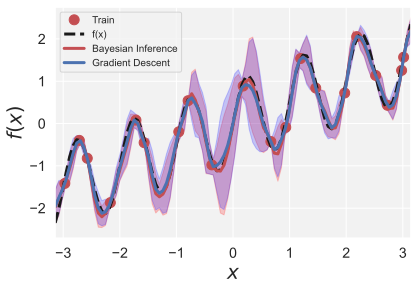

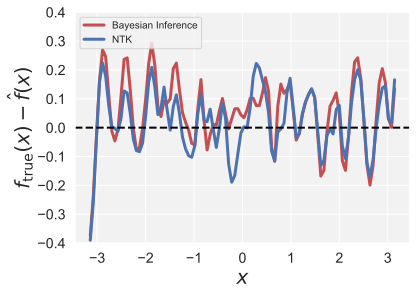

In [26]:
plot_fn(train, test)

plt.plot(test_xs, nngp_mean, 'r-', linewidth=3)
plt.fill_between(
    jnp.reshape(test_xs, (-1)),
    nngp_mean - 2 * nngp_std,
    nngp_mean +  2 * nngp_std,
    color='red', alpha=0.2, label='_nolegend_')
plt.plot(test_xs, ntk_mean, 'b-', linewidth=3)
plt.fill_between(
    jnp.reshape(test_xs, (-1)),
    ntk_mean - 2 * ntk_std,
    ntk_mean +  2 * ntk_std,
    color='blue', alpha=0.2, label='_nolegend_')
plt.xlim([-jnp.pi, jnp.pi])
# plt.ylim([-1.5, 1.5])
legend(['Train', 'f(x)', 'Bayesian Inference', 'Gradient Descent'],
       loc='upper left')
finalize_plot((0.85, 0.6))

residuals_nngp = np.array(test_ys).ravel() - nngp_mean.ravel()
residuals_ntk = np.array(test_ys).ravel() - ntk_mean.ravel()
plt.figure()
plt.plot(test_xs, residuals_nngp.reshape(-1, 1), 'r-', linewidth=3, label='Bayesian Inference')
plt.plot(test_xs, residuals_ntk.reshape(-1, 1), 'b-', linewidth=3, label='NTK')
plt.axhline(0, linestyle='--', color='black', linewidth=2)
format_plot('$x$', r'$f_{\mathrm{true}}(x) - \hat{f}(x)$')
legend(loc='upper left')
finalize_plot((0.85, 0.6))
plt.ylim([-0.4, 0.4])
plt.show()

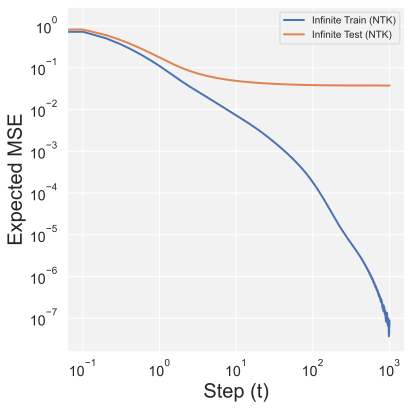

In [32]:
ts = jnp.arange(0, 1e3, 1e-1)
ntk_train_loss_mean = loss_fn(predict_fn, train_ys, ts)
ntk_test_loss_mean  = loss_fn(predict_fn, test_ys, ts, test_xs)

plt.figure(figsize=(6,4))
plt.loglog(ts, ntk_train_loss_mean, linewidth=2, label='Infinite Train (NTK)')
plt.loglog(ts, ntk_test_loss_mean,  linewidth=2, label='Infinite Test (NTK)')
format_plot('Step (t)', 'Expected MSE')
legend(loc='upper right')
finalize_plot()
plt.show()

### Training a NN - het

In [27]:
def phi(x, K=1):
    x = jnp.atleast_2d(x)
    w = 2 * jnp.pi * x
    feats = [x] + [jnp.sin(k*w) for k in range(1, K+1)] + [jnp.cos(k*w) for k in range(1, K+1)]
    return jnp.concatenate(feats, axis=-1)   # shape: (n, 1 + 2K)

# map inputs once
Xtr, ytr = train
Xte, yte = test
Xtr_phi, Xte_phi = phi(Xtr), phi(Xte)


In [44]:
init_het_fn, apply_het_fn, kernel_het_fn = stax.serial(
    stax.Dense(128, W_std=1.5, b_std=0.05), stax.Erf(),
    stax.Dense(128, W_std=1.5, b_std=0.05), stax.Erf(),
    stax.Dense(128, W_std=1.5, b_std=0.05), stax.Erf(),
    stax.Dense(2,  W_std=1.5, b_std=0.05)
)

learning_rate = 1e-3
training_steps = 100000

opt_init, opt_update, get_params = optimizers.sgd(learning_rate)
opt_update = jit(opt_update)

ts_het = jnp.arange(0, training_steps, 1e-1)

In [46]:
def het_nll_loss(params, x, y):
    out = apply_fn(params, phi(x))          # shape (N, 2) or (batch, 2)
    mu = out[..., 0]
    log_var = out[..., 1]

    # numerical stability (optional but recommended)
    log_var = jnp.clip(log_var, -10.0, 10.0)
    var = jnp.exp(log_var)

    nll = 0.5 * ((y - mu)**2 / var + log_var)
    return jnp.mean(nll)

loss_het = jit(lambda params, x, y: het_nll_loss(params, x, y))
grad_loss_het = jit(lambda state, x, y: grad(loss_het)(get_params(state), x, y))

In [47]:
train_losses_het = []
test_losses_het = []
snapshots_het = {}

# evaluation checkpoints
# eval_steps = [0, 16, 256, 2048, 4096, 8192, 10000]
eval_steps = [0, 256, 4096, 10000]

key = random.PRNGKey(0)
_, params = init_het_fn(key, (-1, Xtr_phi.shape[-1]))
opt_state = opt_init(params)

for i in range(training_steps + 1):
    # record predictions at chosen steps
    if i in eval_steps:
        preds = apply_het_fn(get_params(opt_state), Xte_phi)
        snapshots_het[i] = np.asarray(preds[:, 0]).ravel()

    # do SGD update (skip after final step)
    if i < training_steps:
        opt_state = opt_update(i, grad_loss_het(opt_state, *train), opt_state)

        train_losses_het.append(loss_het(get_params(opt_state), *train))
        test_losses_het.append(loss_het(get_params(opt_state), *test))


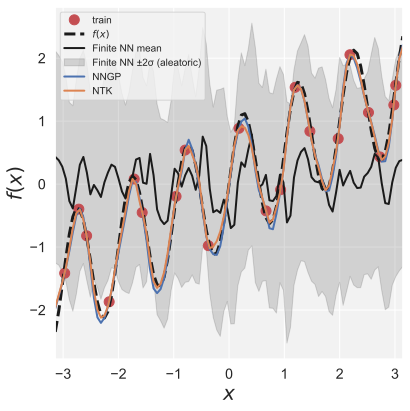

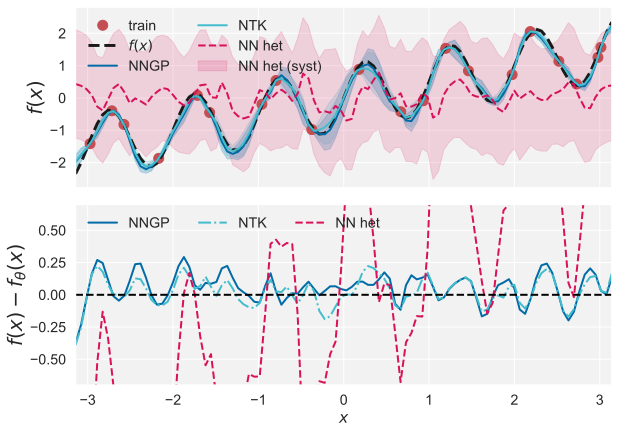

In [50]:
out = apply_het_fn(get_params(opt_state), phi(test_xs))
nn_mean = out[:, 0]
nn_std  = jnp.sqrt(softplus(out[:, 1]))
plt.figure(figsize=(6,4))
plot_fn(train, test)
plt.plot(test_xs, nn_mean, 'k-', linewidth=2, label='Finite NN mean')
plt.fill_between(
    test_xs.reshape(-1),
    nn_mean - 2*nn_std,
    nn_mean + 2*nn_std,
    color='k', alpha=0.15, label='Finite NN ±2σ (aleatoric)'
)
plt.plot(test_xs, nngp_mean, linestyle='-', linewidth=2, label='NNGP')
plt.plot(test_xs, ntk_mean, linestyle='-', linewidth=2, label='NTK')
legend(loc='upper left')
finalize_plot()
plt.show()


# plt.figure(figsize=(6,4))
# plt.loglog(ts, ntk_train_loss_mean, linewidth=2, label='Infinite Train (NTK)')
# plt.loglog(ts, ntk_test_loss_mean,  linewidth=2, label='Infinite Test (NTK)')
# plt.loglog(ts_het, train_losses_het, 'k-', linewidth=1.8, label='Finite het NN (train)')
# plt.loglog(ts_het, test_losses_het,  'k--', linewidth=1.8, label='Finite het NN (test)')
# format_plot('Step (t)', 'Loss')
# legend(loc='upper right')
# finalize_plot()
# plt.show()

# residuals and pred plot
fig, (ax_top, ax_bottom) = plt.subplots(
    2, 1,
    figsize=(5, 7),
    gridspec_kw={'height_ratios': [1, 1]},
    sharex=True            # single shared x-axis
)

plt.sca(ax_top)

plot_fn(train, test)

plt.plot(test_xs, nngp_mean, linestyle='-', color='#006BA6', linewidth=2, label='NNGP')
plt.fill_between(
    jnp.reshape(test_xs, (-1)),
    nngp_mean - nngp_std,
    nngp_mean + nngp_std,
    color='#006BA6', alpha=0.2, label='_nolegend_')

plt.plot(test_xs, ntk_mean, linestyle='-', color='#43BCCD', linewidth=2, label='NTK')
plt.fill_between(
    jnp.reshape(test_xs, (-1)),
    ntk_mean - ntk_std,
    ntk_mean +  ntk_std,
    color='#43BCCD', alpha=0.2, label='_nolegend_')

plt.plot(jnp.reshape(test_xs, (-1,)), nn_mean, linestyle='--', color='#D81159', linewidth=2, label='NN het')
plt.fill_between(
    test_xs.reshape(-1),
    nn_mean - 2*nn_std,
    nn_mean + 2*nn_std,
    color='#D81159', alpha=0.15, label='NN het (syst)'
)


plt.xlim([-jnp.pi, jnp.pi])
plt.legend(
    loc='upper left', frameon=False, ncol=2
)

plt.xlabel(None)
plt.ylabel(r'$f(x)$', fontsize=20)
finalize_plot((0.85, 0.6))


plt.sca(ax_bottom)

residuals_nngp = np.array(test_ys).ravel() - nngp_mean.ravel()
residuals_ntk = np.array(test_ys).ravel() - ntk_mean.ravel()
residuals_net_het = np.array(test_ys).ravel() - nn_mean.ravel()

plt.plot(test_xs, residuals_nngp, linestyle='-', color='#006BA6', linewidth=2, label='NNGP')
plt.plot(test_xs, residuals_ntk, linestyle='-.', color='#43BCCD', linewidth=2, label='NTK')
plt.plot(test_xs, residuals_net_het, linestyle='--', color='#D81159', linewidth=2, label='NN het')

plt.axhline(0, linestyle='--', color='black', linewidth=2)

plt.xlabel('$x$')
plt.ylabel(r'$f(x) - f_{\theta}(x)$', fontsize=20)
plt.legend(loc='upper left', frameon=False, ncol=3)
plt.ylim([-0.7, 0.7])

plt.tight_layout()
plt.savefig("figs/NNGP_NTK_NN_het.pdf")
plt.show()
plt.close()